# Data mining \& clustering

The goal if this practical is to adress the folowing problem:
<center style="color:red" >  Given XXX raw, unlabeled documents, ... How to exploit/understand/represent them?</center>

In the previous week, we have seen how to represent textual data with the Bag of Words (BoW) model:
$$X =
	\begin{matrix}
	 & \textbf{t}_j \\
	 & \downarrow \\
	\textbf{d}_i \rightarrow &
	\begin{pmatrix}
	x_{1,1} & \dots & x_{1,d} \\
	\vdots & \ddots & \vdots \\
	x_{N,1} & \dots & x_{N,d} \\
	\end{pmatrix}
	\end{matrix}
	$$

From this BoW representation, we want to answer the following questions:
1. Which clustering algorithm to choose?
    - K-means, LSA, pLSA, LDA
1. What results to expect?
    - Semantics, noise cleaning, etc...
1. Which qualitative and quantitative analyses to understand the groups?
[comment]: <> (%1. Comment boucler, itérer pour améliorer la qualité du processus?)


<span style="color:magenta" > In this practical, we use a **labeled dataset** in order to evaluate performances with quantitative and well-defined metrics. </span>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import codecs
import re
import os.path
import sklearn

## Data loading



In [2]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

In [3]:
# conversion BoW + tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
#vectorizer = TfidfVectorizer()
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)

# sparsity measure = 44 active words over 1000 per document (157 over 130000) !!
print(vectors.nnz / float(vectors.shape[0]))

(11314, 1000)
44.164928407283014


In [4]:
# retrieve words
print([(i,vectorizer.get_feature_names_out()[i]) \
       for i in np.random.randint(vectors.shape[1], size=10)])

[(530, 'knows'), (524, 'killed'), (690, 'place'), (335, 'dr'), (924, 'uk'), (106, 'answer'), (264, 'controller'), (120, 'aren'), (502, 'internet'), (579, 'makes')]


In [5]:
# labels (only for evaluation)
Y = newsgroups_train.target
print(Y[:10])
print([newsgroups_train.target_names[i] for i in Y[:20]]) # vraie classe

[ 7  4  4  1 14 16 13  3  2  4]
['rec.autos', 'comp.sys.mac.hardware', 'comp.sys.mac.hardware', 'comp.graphics', 'sci.space', 'talk.politics.guns', 'sci.med', 'comp.sys.ibm.pc.hardware', 'comp.os.ms-windows.misc', 'comp.sys.mac.hardware', 'rec.motorcycles', 'talk.religion.misc', 'comp.sys.mac.hardware', 'sci.space', 'misc.forsale', 'alt.atheism', 'comp.graphics', 'rec.autos', 'sci.electronics', 'comp.windows.x']


# 0) Word clouds
### Drawing word clouds from the raw corpus or words' frequencies :  [make word clouds !](https://github.com/amueller/word_cloud)

### Installation
If you are using pip:

`pip install wordcloud`

### If you are using conda, you can install from the conda-forge channel:

`conda install -c conda-forge wordcloud`

### Let's look at the most frequent words in this dataset

In [6]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
data = np.array(newsgroups_train.data)
corpus = "".join(data)
words = corpus.split() # optional args to choose the splitting chars
print("Nb mots=",len(words))
# Lets find the most frequence words Your code here

from collections import Counter

word_counts = Counter(words)
word_counts.most_common(5)

Nb mots= 3252437


[('the', 127670), ('to', 69836), ('of', 66705), ('a', 56148), ('and', 52580)]

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def show_wordcloud(text):
  wc = WordCloud().generate(text)

  plt.figure()
  plt.imshow(wc, interpolation="bilinear")
  plt.axis("off")
  plt.show()

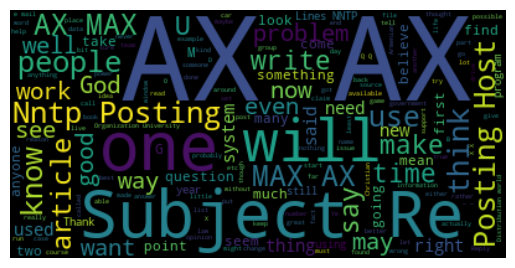

In [13]:
show_wordcloud(corpus)

### Plot the N frequent words and verify that its follows a Zipf law

In [14]:
# Your code here
sorted_count = sorted(word_counts.values(), reverse=True)

Text(0.5, 1.0, 'Zipf of the words')

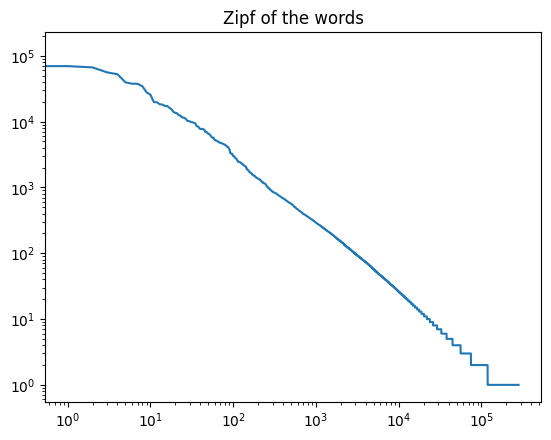

In [15]:
plt.plot(sorted_count)
plt.yscale('log')
plt.xscale("log")
plt.title("Zipf of the words")

### Experiment word clouds

(-0.5, 399.5, 199.5, -0.5)

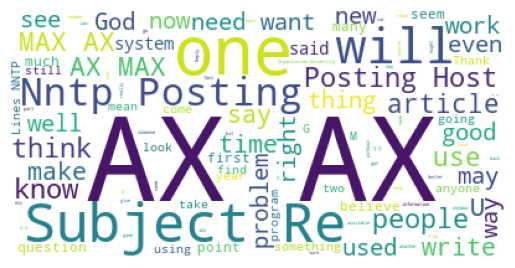

In [17]:
from wordcloud import STOPWORDS # Note: this is the default option
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate(corpus)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")

### Use word clouds with generate\_from\_frequencies.
N.B.: retrieve the most words frequencies using a CountVectorizer

In [29]:
# Your code here
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data)
names_count_vect = vectorizer.get_feature_names_out()
counts = np.array(X.sum(axis=0))[0]
word_counts = dict(zip(names_count_vect, counts))

(-0.5, 399.5, 199.5, -0.5)

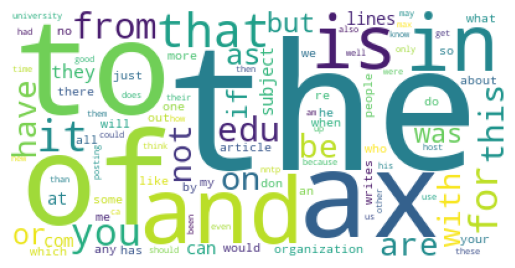

In [31]:
# Your code here
wc = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate_from_frequencies(word_counts)
plt.figure()
plt.imshow(wc)
plt.axis("off")

### Drawing word clouds from classes


In [48]:
def wordcloud_class(data, y, k, names):
  # pass the class number k
  idx = np.where(y == k)[0]
  X_k = data[idx]

  print("class ", names[y[idx[0]]], "size ", len(X_k))

  vectorizer = CountVectorizer(stop_words="english", min_df=0.1)
  X = vectorizer.fit_transform(X_k)
  names_count_vect = vectorizer.get_feature_names_out()
  counts = np.array(X.sum(axis=0))[0]
  word_counts = dict(zip(names_count_vect, counts))

  wc = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate_from_frequencies(word_counts)

  plt.figure()
  plt.imshow(wc)
  plt.axis("off")
  plt.show()

class  alt.atheism size  480


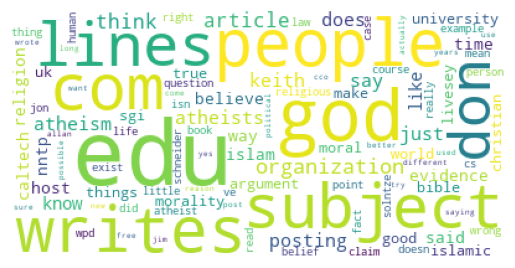

class  comp.graphics size  584


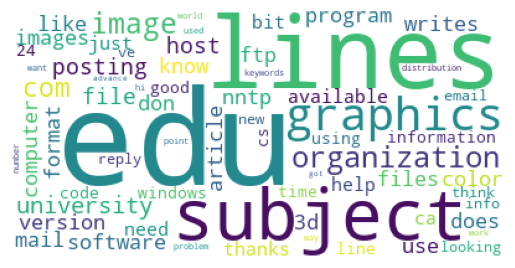

class  comp.os.ms-windows.misc size  591


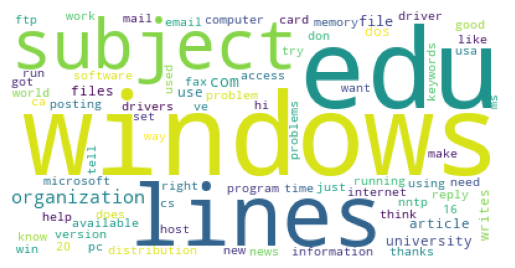

class  comp.sys.ibm.pc.hardware size  590


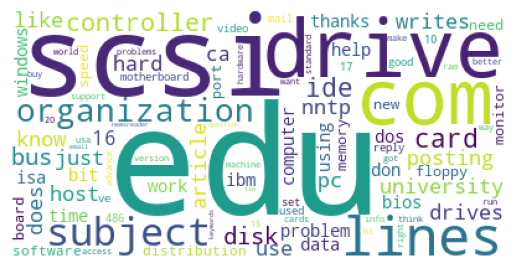

class  comp.sys.mac.hardware size  578


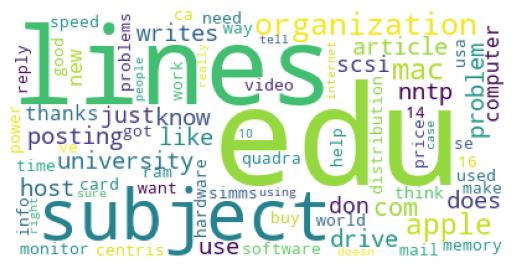

class  comp.windows.x size  593


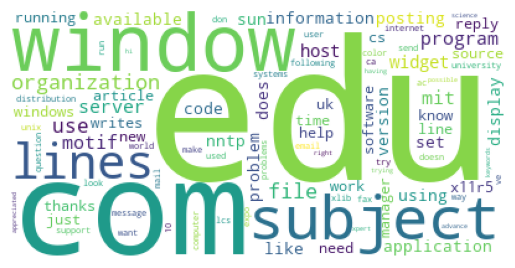

class  misc.forsale size  585


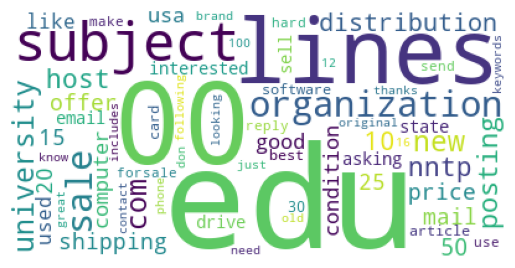

class  rec.autos size  594


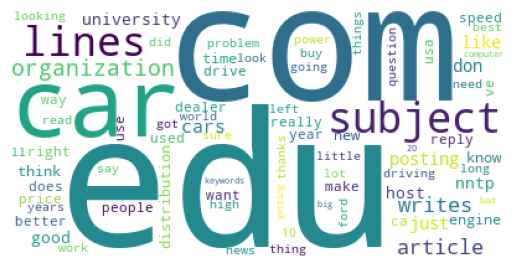

class  rec.motorcycles size  598


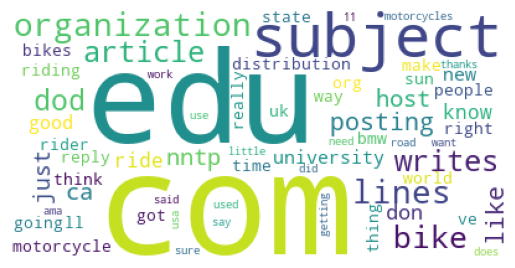

class  rec.sport.baseball size  597


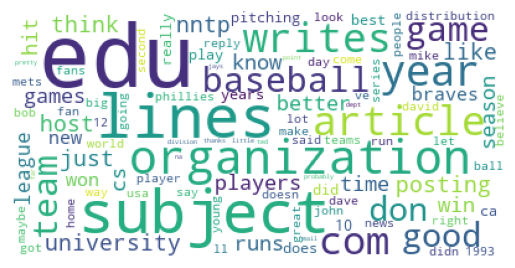

class  rec.sport.hockey size  600


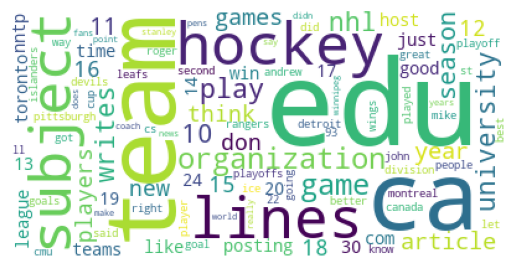

class  sci.crypt size  595


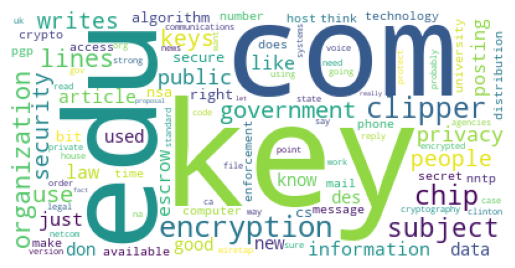

class  sci.electronics size  591


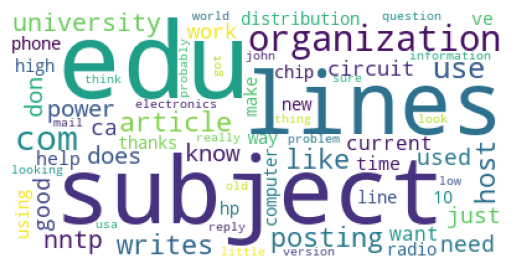

class  sci.med size  594


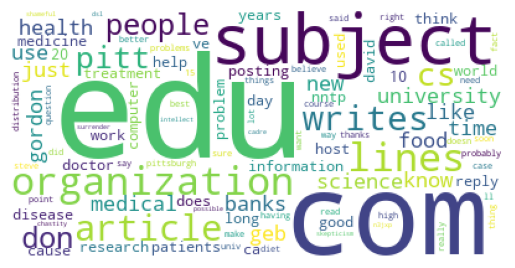

class  sci.space size  593


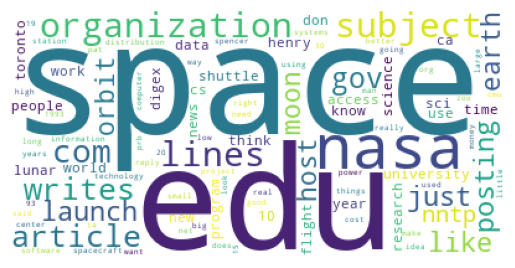

class  soc.religion.christian size  599


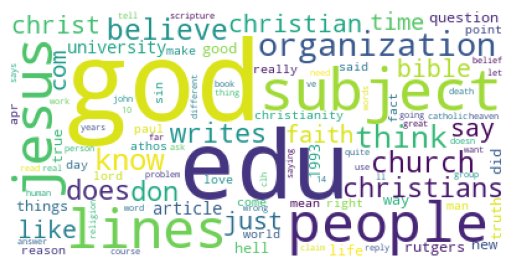

class  talk.politics.guns size  546


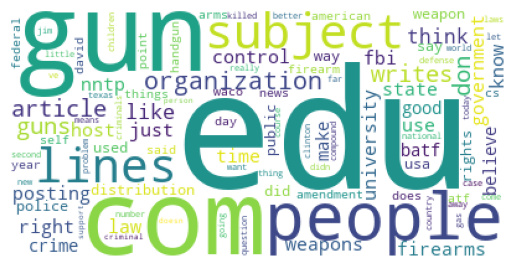

class  talk.politics.mideast size  564


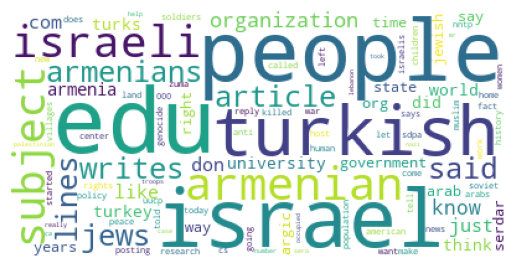

class  talk.politics.misc size  465


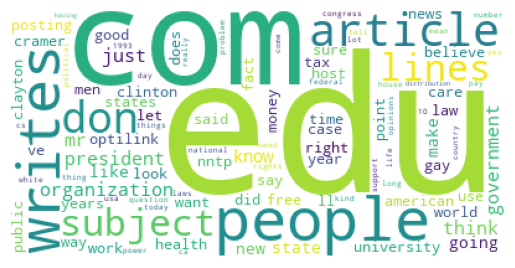

class  talk.religion.misc size  377


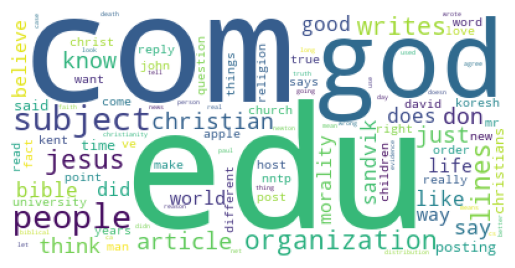

In [49]:
for k in np.unique(Y):
  wordcloud_class(data, Y, k, newsgroups_train.target_names)

# 1) Clustering algorithm: K-Means

**Let's start by the most famous and simple unsupervised algorithm: $k$-means!**
Look at [sklear documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
and apply it to your BoW matrix.


In [50]:
from sklearn.cluster import KMeans
# your code here
kmeans = KMeans(n_clusters=20, random_state=0, max_iter=10).fit(vectors)
# Getting clusters:
kmeans.cluster_centers_

array([[0.10756056, 0.02727664, 0.01102787, ..., 0.00212592, 0.00593682,
        0.00501284],
       [0.00523323, 0.01669429, 0.00168778, ..., 0.00636396, 0.00279291,
        0.0026637 ],
       [0.00212163, 0.00200874, 0.00086759, ..., 0.00221913, 0.00042353,
        0.        ],
       ...,
       [0.00234538, 0.00195804, 0.00063837, ..., 0.0051056 , 0.00321528,
        0.00236145],
       [0.00252404, 0.00392048, 0.002013  , ..., 0.00594924, 0.00468899,
        0.00315283],
       [0.00374857, 0.00500582, 0.00028979, ..., 0.00708021, 0.01223925,
        0.01180756]])

### Clustering Analysis:
1. **Qualtitative:**
    - Look at the most important words for each cluster
    - Perform cluster assignement to each document, and compute word cloud on the document (raw text or frequencies)
2. **Quantitative:**
    - Compute cluster "purity": $p_j= |y^*_j|$, where $y^*_j$ is the most frequent (GT) label in cluster $C_j$ $\Rightarrow$ $p = \frac{1}{N}\sum\limits_j  p_j$
    - Compute [Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html) and [Adjusted Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html#sklearn.metrics.adjusted_rand_score)

In [62]:
# qualitative
for label in np.unique(kmeans.labels_):
  idx = np.where(kmeans.labels_ == label)[0]
  data_label = data[idx]

  vectorizer = CountVectorizer(stop_words="english")
  X = vectorizer.fit_transform(data_label)
  names_count_vect = vectorizer.get_feature_names_out()
  counts = X.sum(axis=0).A1

  idx = np.argsort(counts)[::-1][:10]
  print(label, data_label.shape[0], names_count_vect[idx])


0 421 ['00' '10' 'edu' '25' 'sale' '15' 'lines' 'subject' '20' '11']
1 306 ['car' 'edu' 'com' 'subject' 'lines' 'organization' 'article' 'writes'
 'cars' 'just']
2 261 ['drive' 'scsi' 'edu' 'ide' 'drives' 'hard' 'disk' 'controller' 'lines'
 'subject']
3 337 ['uk' 'ac' 'subject' 'lines' 'organization' 'edu' 'writes' 'university'
 'article' 'com']
4 322 ['key' 'encryption' 'chip' 'clipper' 'com' 'keys' 'edu' 'government' 'use'
 'subject']
5 570 ['god' 'jesus' 'edu' 'people' 'believe' 'subject' 'don' 'does' 'think'
 'lines']
6 97 ['edu' 'pitt' 'gordon' 'banks' 'geb' 'cs' 'article' 'writes' 'subject'
 'lines']
7 241 ['com' 'netcom' 'organization' 'subject' 'lines' 'writes' 'edu' 'article'
 '408' 'services']
8 700 ['people' 'edu' 'government' 'israel' 'don' 'subject' 'said' 'think'
 'writes' 'like']
9 380 ['edu' 'uiuc' 'subject' 'writes' 'lines' 'organization' 'university' 'cso'
 'cc' 'article']
10 263 ['nasa' 'space' 'gov' 'edu' 'subject' 'lines' 'organization' 'jpl'
 'article' 'writes']
1

In [ ]:
# quantitative

from sklearn import metrics

# purity score
def purity_score(y_true, y_pred):
    # compute contingency matrix (also called confusion matrix)
    contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)
    # return purity
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix) 

lst_purity = []

for i in np.unique(kmeans.labels_):
  idx = np.where(kmeans.labels_ == i)[0] # getting cluster
  purr = purity_score(Y[idx], kmeans.labels_[idx])
  print("Cluster ", i, " purity ", purr)
  lst_purity.append(purr) # higher purity, better

rand = metrics.rand_score(Y, kmeans.labels_) # similarity between the 2 clusterings, close to 1 the 2 clusterings are identical
ad_rand = metrics.adjusted_rand_score(Y, kmeans.labels_) # close to 0 random labelling, close to 1 clustering identical, adjusted for chance
rand, ad_rand

Cluster  0  purity  0.6152019002375297
Cluster  1  purity  0.7745098039215687
Cluster  2  purity  0.5517241379310345
Cluster  3  purity  0.1543026706231454
Cluster  4  purity  0.953416149068323
Cluster  5  purity  0.6210526315789474
Cluster  6  purity  0.979381443298969
Cluster  7  purity  0.14522821576763487
Cluster  8  purity  0.53
Cluster  9  purity  0.07631578947368421
Cluster  10  purity  0.46387832699619774
Cluster  11  purity  0.36726804123711343
Cluster  12  purity  0.2392638036809816
Cluster  13  purity  0.15789473684210525
Cluster  14  purity  0.10167253521126761
Cluster  15  purity  0.2971014492753623
Cluster  16  purity  0.20430107526881722
Cluster  17  purity  0.11463414634146342
Cluster  18  purity  0.12884753042233357
Cluster  19  purity  0.6074380165289256


(0.8823682422919308, 0.10730567395686359)

(array([4., 3., 2., 1., 1., 0., 1., 2., 2., 1., 0., 1., 0., 0., 2.]),
 array([0.07631579, 0.13652017, 0.19672454, 0.25692892, 0.3171333 ,
        0.37733767, 0.43754205, 0.49774643, 0.5579508 , 0.61815518,
        0.67835956, 0.73856394, 0.79876831, 0.85897269, 0.91917707,
        0.97938144]),
 <BarContainer object of 15 artists>)

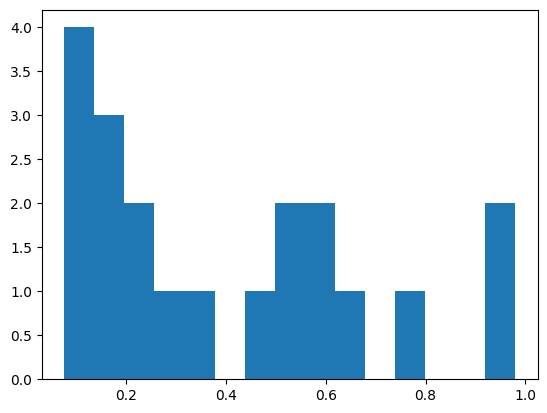

In [65]:
plt.hist(lst_purity, bins=15)

### Multiplier centroid par vecteur V pour avoir les mots  

# 2) Latent Semantic Analysis (LSA <=> SVD)


**Remember the LSA factorziation**:
$$
\begin{matrix}
 & X  &\!\!\!\!\!=\!\!\!\!\!& U  & \Sigma & V^T \\
  & \textbf{t}_j   &  & \hat{ \textbf{d}_i} & &  \\
 & \downarrow  &  &\downarrow  & & \\
\textbf{d}_i \rightarrow
&
\begin{pmatrix}
x_{1,1} & \dots & x_{1,d} \\
\\
\vdots & \ddots & \vdots \\
\\
x_{N,1} & \dots & x_{N,d} \\
\end{pmatrix}
&
\!\!\!\!\!=\!\!\!\!\!
%&
%(\hat{ \textbf{t}_j}) \rightarrow
&
\begin{pmatrix}
\begin{pmatrix} &  \textbf{u}_1 &  \end{pmatrix} \\
\vdots \\
\begin{pmatrix}  & \textbf{u}_k &  \end{pmatrix}
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\sigma_1 & \dots & 0 \\
\vdots & \ddots & \vdots \\
0 & \dots & \sigma_k \\
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\begin{pmatrix} \, \\ \, \\ \textbf{v}_1 \\ \, \\ \,\end{pmatrix}
\dots
\begin{pmatrix} \, \\ \, \\ \textbf{v}_k \\ \, \\ \, \end{pmatrix}
\end{pmatrix}
\end{matrix}
$$

- Look at [SVD doc in skelarn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD)
- Do the same qualitative/quantitative evaluation than with K-Means
- You can also use LSA as a pre-processing step for K-Means, *i.e.* running K-Means on $\boldsymbol{U}$ matrix above
    - N.B. : try without/with $\ell_2$ normalization of $\boldsymbol{U}$'s rows before running  K-Means
    - You can also benefit from LSA pre-processing for using [t-SNE visualization](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (see code below)


#### U * sigma pour kmeans après

In [112]:
from sklearn.decomposition import TruncatedSVD 

vectorizer = CountVectorizer(stop_words="english")
vectorizer.fit(data)
vectors = vectorizer.transform(data)

svd = TruncatedSVD(n_components=10, n_iter=7, random_state=42) # choice of nb components
U = svd.fit_transform(vectors) # already U * S
kmeans = KMeans(n_clusters=10)
kmeans.fit(U)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [113]:
clust_V = kmeans.cluster_centers_ @ svd.components_ # centre * V -> trouver mots dans clusters
clust_V.shape # 20 clusters

(10, 129796)

In [114]:
# 10 latent space and 20 clusters
feat_names = vectorizer.get_feature_names_out()
clust_V = svd.inverse_transform(kmeans.cluster_centers_) 
for i in range(kmeans.cluster_centers_.shape[0]):
    top_words = feat_names[np.argsort(np.abs(clust_V[i]))[::-1][:10]]
    print(f"Cluster {i}:", top_words)

Cluster 0: ['edu' 'com' 'people' 'don' 'subject' 'know' 'like' 'use' 'just' 'think']
Cluster 1: ['ax' 'max' 'pl' '1t' 'bhj' '3t' 'giz' 'b8f' '75u' 'a86']
Cluster 2: ['ax' 'max' 'b8f' 'a86' 'g9v' '145' '1d9' '0t' 'pl' '34u']
Cluster 3: ['ax' 'max' 'pl' '1t' 'bhj' '3t' 'giz' 'b8f' '75u' '7ey']
Cluster 4: ['ax' 'max' 'b8f' 'a86' '145' '1d9' 'pl' '0t' '34u' '2di']
Cluster 5: ['ax' 'max' 'pl' '1t' 'bhj' '3t' 'giz' '75u' 'b8f' '7ey']
Cluster 6: ['ax' 'max' 'pl' 'g9v' 'a86' 'b8f' '1t' '3t' '0d' 'bhj']
Cluster 7: ['ax' 'max' 'g9v' 'b8f' 'a86' '1d9' '75u' 'pl' '2di' 'mg9v']
Cluster 8: ['ax' 'max' 'b8f' 'a86' 'g9v' 'pl' '1d9' '145' '1t' '0t']
Cluster 9: ['file' 'edu' 'com' 'use' 'output' 'program' 'available' 'information'
 'pub' 'ftp']


In [115]:
# t-SNE from the U matrix computed by LSA
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, init='pca',max_iter=5000, verbose=2)
tsne_mat = tsne.fit_transform(U)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 11314 samples in 0.039s...
[t-SNE] Computed neighbors for 11314 samples in 2.088s...
[t-SNE] Computed conditional probabilities for sample 1000 / 11314
[t-SNE] Computed conditional probabilities for sample 2000 / 11314
[t-SNE] Computed conditional probabilities for sample 3000 / 11314
[t-SNE] Computed conditional probabilities for sample 4000 / 11314
[t-SNE] Computed conditional probabilities for sample 5000 / 11314
[t-SNE] Computed conditional probabilities for sample 6000 / 11314
[t-SNE] Computed conditional probabilities for sample 7000 / 11314
[t-SNE] Computed conditional probabilities for sample 8000 / 11314
[t-SNE] Computed conditional probabilities for sample 9000 / 11314
[t-SNE] Computed conditional probabilities for sample 10000 / 11314
[t-SNE] Computed conditional probabilities for sample 11000 / 11314
[t-SNE] Computed conditional probabilities for sample 11314 / 11314
[t-SNE] Mean sigma: 0.148162
[t-SNE] Computed cond

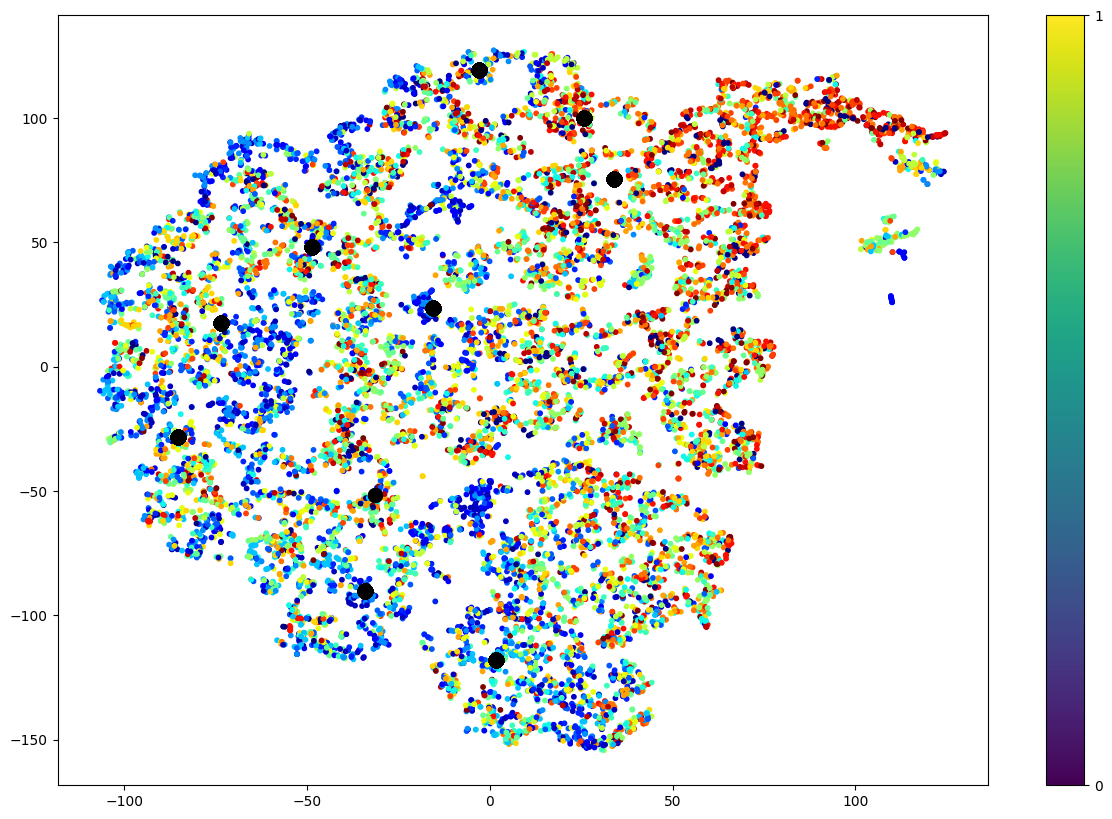

In [116]:
vectors_SVDn = svd.components_ # V matrix
NN2cluster = np.argmax(np.abs(vectors_SVDn), axis=0)
#import seaborn as sns
import matplotlib.cm as cm
from matplotlib.pyplot import get_cmap
cmap = cm.tab20
cmap = get_cmap('hsv', 20)
cmap = get_cmap('jet', 20)
#cmap = cm.tab20

plt.figure(figsize=(15,10))
plt.scatter(tsne_mat[:,0],tsne_mat[:,1], c=Y, cmap=cmap, s=10)
plt.scatter(tsne_mat[NN2cluster[:],0],tsne_mat[NN2cluster[:],1], c='black', s=100)
#plt.scatter(tsne_mat[NN2cluster2[:],0],tsne_mat[NN2cluster2[:],1], c='red', s=100)
plt.colorbar(ticks=range(20))

# 3) Latent Dirichlet Allocation (LDA)

Perform the same experiments with LDA:
- LDA
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html


**Start with a CountVectorizer**

In [117]:
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Initialize regex tokenizer
tokenizer = RegexpTokenizer(r'\w+')

# Vectorize document using TF-IDF
vectorizer = CountVectorizer(lowercase=True,
                        stop_words='english',
                        ngram_range = (1,1),
                        tokenizer = tokenizer.tokenize, max_df=0.95, min_df=2, max_features=1000)

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)
print(vectors.nnz / float(vectors.shape[0]))

/home/franciline/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(11314, 1000)
48.02527841612162


In [119]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=15) # for the 15 topics
M = lda.fit_transform(vectors)

In [ ]:
M.shape # mots vs topics

(11314, 15)

In [ ]:
topics = np.argmax(M, axis=1) # taking the max is a clutering way 
# can apply kmeans after lda, as we have a new representation dimension

In [126]:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(M)
labels = kmeans.labels_

In [127]:
# top words per topic
feat_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = feat_names[np.argsort(topic)[::-1][:10]]
    print(f"Topic {topic_idx}:", top_words)

Topic 0: ['edu' 's' 't' 'ca' 'game' 'team' 'year' 'games' 'play' 'university']
Topic 1: ['drive' 'scsi' 'disk' 'hard' 's' 'drives' 'controller' '2' 'ide' 'bus']
Topic 2: ['0' '1' 'm' '2' 'w' '3' '4' 'r' '5' '6']
Topic 3: ['edu' 'mail' 'uk' 'university' 'ac' 'cs' 'information' 'e' 'available'
 'computer']
Topic 4: ['t' 's' 'like' 'just' 'don' 'time' 'car' 'nasa' 'm' 'good']
Topic 5: ['s' 'q' 'mr' 'president' 'clinton' 't' 'going' 'stephanopoulos' 'tax'
 'think']
Topic 6: ['com' 't' 'writes' 'article' 'edu' 's' 'posting' 'don' 'nntp' 'host']
Topic 7: ['x' 'file' 'window' 'windows' '1' 'program' 's' '0' 'c' 'use']
Topic 8: ['1' 'com' 'edu' '2' 'card' 'ibm' 'windows' 'hp' '3' 'posting']
Topic 9: ['key' 'government' 'edu' 'state' 'encryption' 'chip' 'clipper' 's'
 'access' 'law']
Topic 10: ['ax' 'max' 'q' '3' 'p' 'm' '7' 'r' 'g9v' 'g']
Topic 11: ['t' 's' 'people' 'god' 'edu' 'think' 'don' 'say' 'just' 'know']
Topic 12: ['edu' '_' 'university' 'article' 'writes' 'posting' 'host' 'nntp' 'cc'


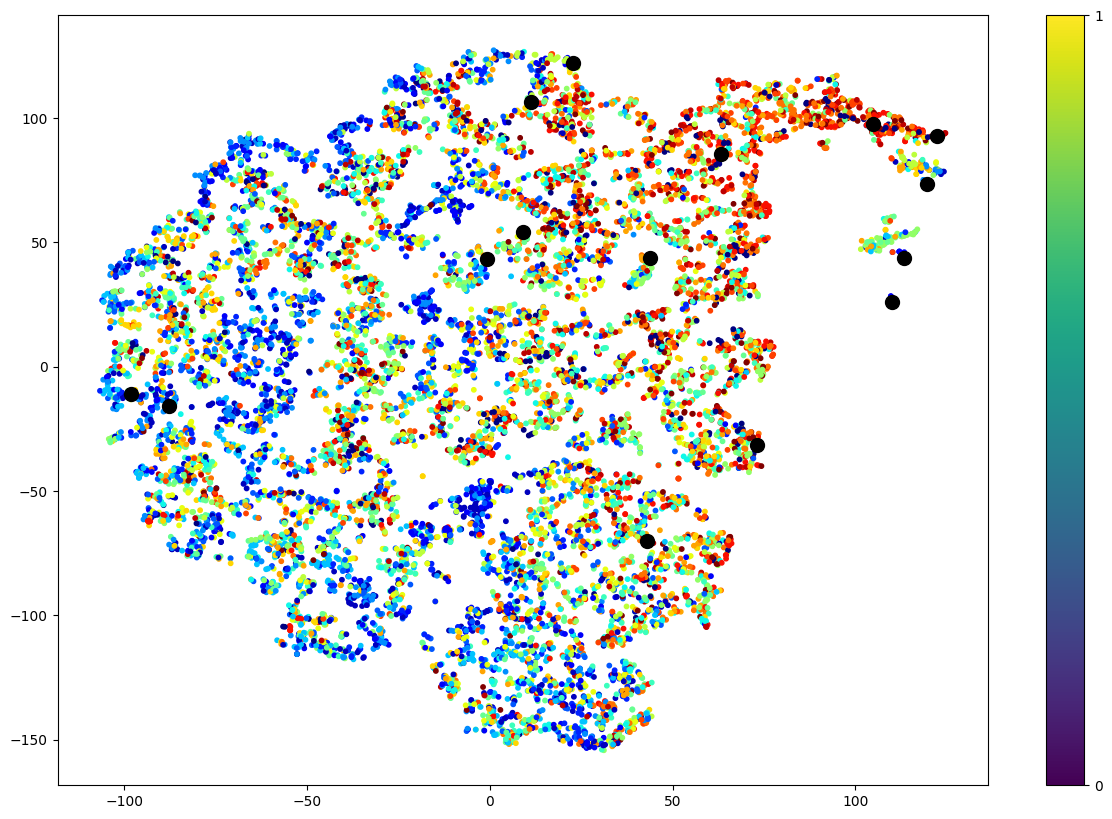

In [132]:
NN2cluster = np.argmax(np.abs(M), axis=0) 
#import seaborn as sns
import matplotlib.cm as cm
from matplotlib.pyplot import get_cmap
cmap = cm.tab20
cmap = get_cmap('hsv', 20)
cmap = get_cmap('jet', 20)
#cmap = cm.tab20

plt.figure(figsize=(15,10))
plt.scatter(tsne_mat[:,0],tsne_mat[:,1], c=Y, cmap=cmap, s=10,)
plt.scatter(tsne_mat[NN2cluster[:],0],tsne_mat[NN2cluster[:],1], c='black', s=100)
plt.colorbar(ticks=range(20))
# plt.legend()
#plt.scatter(tsne_mat[NN2cluster2[:],0],tsne_mat[NN2cluster2[:],1], c='red', s=100)

## LDA-viz

In [152]:
!pip install pyldavis==3.4.0

/home/franciline/anaconda3/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=15458) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 2.2 MB/s  0:00:01 eta 0:00:010m
  Attempting uninstall: pyldavis
    Found existing installation: pyLDAvis 3.4.1
    Uninstalling pyLDAvis-3.4.1:
      Successfully uninstalled pyLDAvis-3.4.1


In [169]:
# # pip install install pyldavis
# from __future__ import print_function

# import pyLDAvis
# import pyLDAvis.sklearn
# pyLDAvis.enable_notebook()

# pyLDAvis.sklearn.prepare(lda,vectors,vectorizer)

In [ ]:
# pip install install pyldavis
from __future__ import print_function

import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

data_prepared = pyLDAvis.lda_model.prepare(lda,vectors,vectorizer)

# Performances evaluation

**Compare the different approaches wrt three quantitative metrics.**